In [3]:
import pandas as pd

df  = pd.read_csv("dataset.csv")

C:\Users\aceteam\AppData\Local\Temp\ipykernel_18108\3847385991.py:3: DtypeWarning: Columns (0: Consumer Claim, 1: Consumer consent provided?, 2: Consumer disputed?) have mixed types. Specify dtype option on import or set low_memory=False.
  df  = pd.read_csv("dataset.csv")


# Identification des colonnes

In [4]:

df.head()

,Date received,Tag,Consumer Claim,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,05/10/2019,Checking or savings account,NaN,NaN,NAVY FEDERAL CREDIT UNION,FL,328XX,Older American,NaN,Web,05/10/2019,In progress,Yes,NaN,3238275
1,05/10/2019,Checking or savings account,NaN,NaN,BOEING EMPLOYEES CREDIT UNION,WA,98204,NaN,NaN,Referral,05/10/2019,Closed with explanation,Yes,NaN,3238228
2,05/10/2019,Debt collection,NaN,NaN,CURO Intermediate Holdings,TX,751XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3237964
3,05/10/2019,"Credit reporting, credit repair services, or o...",NaN,NaN,Ad Astra Recovery Services Inc,LA,708XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3238479
4,05/10/2019,Checking or savings account,NaN,NaN,ALLY FINANCIAL INC.,AZ,85205,NaN,NaN,Postal mail,05/10/2019,In progress,Yes,NaN,3238460


In [5]:
for column in df.columns:
    print(column)
    print("-------------------------")
    print(df[column].drop_duplicates())
    print("\n")

Date received
-------------------------
0          05/10/2019
17         05/09/2019
67         05/08/2019
146        05/07/2019
230        05/06/2019
              ...    
1281885    12/05/2011
1282049    12/04/2011
1282071    12/03/2011
1282097    12/02/2011
1282235    12/01/2011
Name: Date received, Length: 2717, dtype: str


Tag
-------------------------
0                               Checking or savings account
2                                           Debt collection
3         Credit reporting, credit repair services, or o...
5                                                  Mortgage
7                                              Student loan
10                                    Vehicle loan or lease
50                              Credit card or prepaid card
61                Payday loan, title loan, or personal loan
151       Money transfer, virtual currency, or money ser...
513855                                     Credit reporting
513857                                  

In [14]:
analysis = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "n_unique": df.nunique()
})

analysis.sort_values("missing_pct", ascending=False)

,dtype,missing,missing_pct,n_unique
Tags,str,1106712,86.303091,3
Consumer Claim,str,898791,70.089094,366945
Company public response,str,833273,64.979900,10
Consumer consent provided?,str,591701,46.141747,4
Consumer disputed?,str,513854,40.071119,2
ZIP code,str,115298,8.991114,22591
State,str,19400,1.512842,63
Company response to consumer,str,7,0.000546,8
Company,str,0,0.000000,5275
Date received,str,0,0.000000,2717


In [6]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1282355 entries, 0 to 1282354
Data columns (total 15 columns):
 #   Column                        Non-Null Count    Dtype
---  ------                        --------------    -----
 0   Date received                 1282355 non-null  str  
 1   Tag                           1282355 non-null  str  
 2   Consumer Claim                383564 non-null   str  
 3   Company public response       449082 non-null   str  
 4   Company                       1282355 non-null  str  
 5   State                         1262955 non-null  str  
 6   ZIP code                      1167057 non-null  str  
 7   Tags                          175643 non-null   str  
 8   Consumer consent provided?    690654 non-null   str  
 9   Submitted via                 1282355 non-null  str  
 10  Date sent to company          1282355 non-null  str  
 11  Company response to consumer  1282348 non-null  str  
 12  Timely response?              1282355 non-null  str  
 13  Consumer

|  #  | Column                        | Nullable ?   | Description              | Valeurs
| --- | ------                        | ------------ | --------------           | --------------
| 0   | Date received                 | N            | Date de réception | DATE
| 1   | Tag                           | N            | Etiquette (A prédire)
| 2   | Consumer Claim                | Y            | Message de la réclamation client
| 3   | Company public response       | Y            | Réponse de l'entreprise
| 4   | Company                       | N            | Nom de l'entreprise
| 5   | State                         | Y            | Code de l'état | ex: "FL" ou texte si hors US "UNITED STATES MINOR OUTLYING ISLANDS" 
| 6   | ZIP code                      | Y            | Code postal
| 7   | Tags                          | Y            | Etiquettes d'information complémentaires sur le client
| 8   | Consumer consent provided?    | Y            | Le consentement du consommateur a-t-il été obtenu ?
| 9   | Submitted via                 | N            | Type de soumission de la réclamation | Web, Referral, Postal mail, Phone, Fax, Email
| 10  | Date sent to company          | N            | Date d'envoi à l'entreprise | DATE
| 11  | Company response to consumer  | Y            | Status de la réponse de l'entreprise
| 12  | Timely response?              | N            | Réponse rapide ? | Yes, No
| 13  | Consumer disputed?            | Y            | Contesté par le consommateur ? | Yes, No
| 14  | Complaint ID                  | N            | Identifiant de la ligne | UNIQUE ID


# Exploration des données

## valeurs vides

Pour rappel Pandas différencie 4 types de données absentes


|Valeur| Signification             | Utilisée pour
|------|---------------------------|--------------------------------------------------
|NaN   | Not a Number              | Données numériques, mais aussi colonnes object
|None  | Absence de valeur Python  | Objets Python
|NaT   | Not a Time                | Dates et heures
|""    | Chaine vide               | Chaines de caractères

In [7]:
# obtient les colonnes entiérement vides (NaN, None, NaT et "")
colonnes_vides = df.replace("", pd.NA).isna().all()

print(colonnes_vides)

Date received                   False
Tag                             False
Consumer Claim                  False
Company public response         False
Company                         False
State                           False
ZIP code                        False
Tags                            False
Consumer consent provided?      False
Submitted via                   False
Date sent to company            False
Company response to consumer    False
Timely response?                False
Consumer disputed?              False
Complaint ID                    False
dtype: bool


In [8]:
# nombre de cellules vides par colonne
nb_colonnes_vides = df.apply(lambda col: (col == "").sum())

print(nb_colonnes_vides)

Date received                   0
Tag                             0
Consumer Claim                  0
Company public response         0
Company                         0
State                           0
ZIP code                        0
Tags                            0
Consumer consent provided?      0
Submitted via                   0
Date sent to company            0
Company response to consumer    0
Timely response?                0
Consumer disputed?              0
Complaint ID                    0
dtype: int64


In [9]:
# nombre de cellules nulles par colonne
nb_colonnes_nulles = df.isna().sum()

print(nb_colonnes_nulles)

Date received                         0
Tag                                   0
Consumer Claim                   898791
Company public response          833273
Company                               0
State                             19400
ZIP code                         115298
Tags                            1106712
Consumer consent provided?       591701
Submitted via                         0
Date sent to company                  0
Company response to consumer          7
Timely response?                      0
Consumer disputed?               513854
Complaint ID                          0
dtype: int64


## "Consumer Claim" non renseigné

Beaucoups de valeurs de la colonne "Consumer Claim" sont à NULL, hors cette variable est la variable d'entrée de la demande
Dans le contexte d'un système de gestion des réclamations, plusieurs explications sont possibles...

### 1. Le texte de la réclamation n'est pas systématiquement publié
La colonne "Consumer consent provided?" indique si le client a donner son consentement
Il serait intéressant de vérifier directement la relation entre ces 2 colonnes

In [19]:
result = df.groupby("Consumer consent provided?")["Consumer Claim"].agg(
    total="size",
    non_null=lambda x: x.notna().sum(),
    null=lambda x: x.isna().sum()
)


result["available_percent"] = (
    result["non_null"] / result["total"] * 100
)

result

,total,non_null,null,available_percent
Consumer consent provided?,,,,
Consent not provided,285087,0,285087,0.000000
Consent provided,383885,383564,321,99.916381
Consent withdrawn,1200,0,1200,0.000000
Other,20482,0,20482,0.000000


### 2. Les anciennes réclamations peuvent avoir été enregistrées sans texte

Il est possible que le système ait évolué au fil du temps
* initialement, seules les informations administratives et catégorielles étaient publiées ;
* plus tard, le texte de la réclamation a été ajouté ;
* ou les règles de publication et d'anonymisation ont changé.

In [ ]:
df["Date received"] = pd.to_datetime(
    df["Date received"],
    dayfirst=False
)

missing_by_year = (
    df.assign(
        has_claim=df["Consumer Claim"].notna()
    )
    .groupby(df["Date received"].dt.year)["has_claim"]
    .agg(["count", "mean"])
)

missing_by_year["missing_percent"] = (
    1 - missing_by_year["mean"]
) * 100

print(missing_by_year)

                count      mean  missing_percent
Date received                                   
2011             2536  0.000000       100.000000
2012            72373  0.000000       100.000000
2013           108218  0.000000       100.000000
2014           153047  0.000000       100.000000
2015           168487  0.324998        67.500163
2016           191473  0.406444        59.355627
2017           242975  0.474008        52.599239
2018           257379  0.460329        53.967107
2019            85867  0.201847        79.815296


<Axes: xlabel='Date received'>

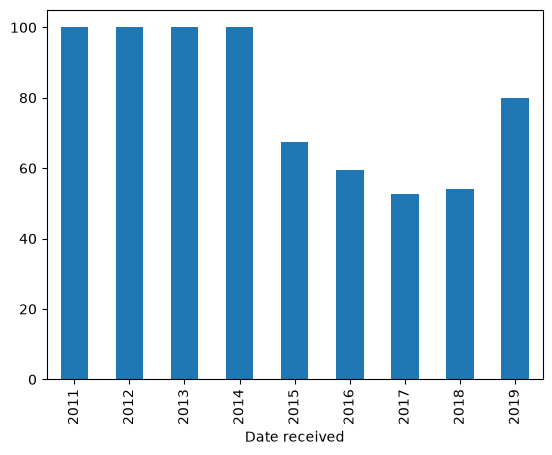

In [ ]:
(
    df.groupby(df["Date received"].dt.year)["Consumer Claim"]
    .apply(lambda x: x.isna().mean() * 100)
    .plot(kind="bar")
)

### 3. Certaines réclamations peuvent provenir de sources qui ne transmettent pas le texte

La colonne Submitted via contient notamment :

In [ ]:
result = (
    df.groupby("Submitted via")["Consumer Claim"]
    .agg(
        total="size",
        available=lambda x: x.notna().sum()
    )
)

result["available_percent"] = (
    result["available"] / result["total"] * 100
)

print(result.sort_values("available_percent"))

                total  available  available_percent
Submitted via                                      
Email             383          0           0.000000
Fax             18972          0           0.000000
Phone           76509          0           0.000000
Postal mail     67522          0           0.000000
Referral       173640          0           0.000000
Web            945329     383564          40.574657


In [ ]:
pd.crosstab(
    df["Submitted via"],
    df["Consumer Claim"].isna(),
    normalize="index"
) * 100

Consumer Claim,False,True
Submitted via,,
Email,0.000000,100.000000
Fax,0.000000,100.000000
Phone,0.000000,100.000000
Postal mail,0.000000,100.000000
Referral,0.000000,100.000000
Web,40.574657,59.425343


## Doublons dans les ids ?

In [ ]:
# Complaint ID contient des doublons ?

print(df["Complaint ID"].duplicated().sum())

0


# Adresse

In [ ]:
# l'état appartient'il à l'entreprise ou au client ?

# les entreprises ont un code postal unique ? NON
print(df.groupby("Company")["State"].nunique())

Company
(Former)Shapiro, Swertfeger & Hasty, LLP     8
1 STOP MONEY CENTERS, LLC                    1
10 Cent Title Pawn Inc                       1
1ST 2ND MORTGAGE CO. OF NJ INC               1
1ST ALLIANCE LENDING, LLC                   12
                                            ..
loanDepot.com, LLC                          48
reekside Recovery And Capital Management    13
snw investments                              1
xCoins, Inc.                                 1
 Lippman Recupero, LLC                       2
Name: State, Length: 5275, dtype: int64


In [ ]:
# le code postal appartient'il à l'entreprise ou au client ?

# les entreprises ont un code postal unique ? NON
print(df.groupby("Company")["ZIP code"].nunique())

Company
(Former)Shapiro, Swertfeger & Hasty, LLP     11
1 STOP MONEY CENTERS, LLC                     3
10 Cent Title Pawn Inc                        1
1ST 2ND MORTGAGE CO. OF NJ INC                1
1ST ALLIANCE LENDING, LLC                    17
                                           ... 
loanDepot.com, LLC                          485
reekside Recovery And Capital Management     24
snw investments                               1
xCoins, Inc.                                  1
 Lippman Recupero, LLC                        5
Name: ZIP code, Length: 5275, dtype: int64


In [ ]:
# Colonnes avec toutes les valeurs identiques
cols_constantes = [
    col for col in df.columns
    if df[col].nunique() == 1
]
display(cols_constantes)

[]

# Distribution des étiquettes

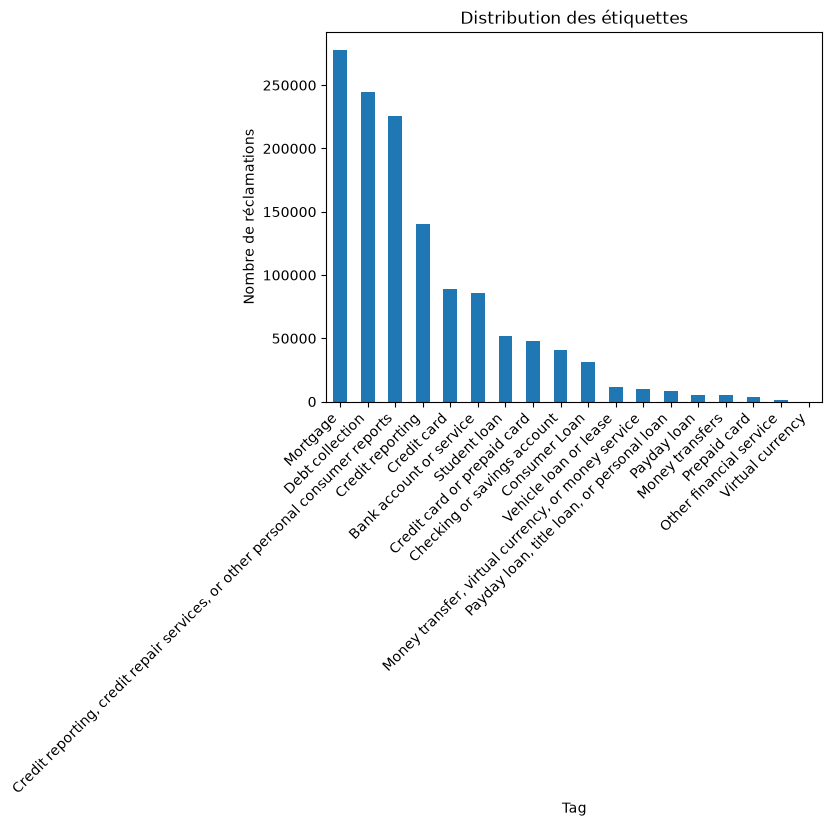

In [ ]:
import matplotlib.pyplot as plt

df["Tag"].value_counts().plot(kind="bar")

plt.xlabel("Tag")
plt.ylabel("Nombre de réclamations")
plt.title("Distribution des étiquettes")
plt.xticks(rotation=45, ha="right")
plt.show()

In [ ]:
class_distribution = (
    df["Tag"]
    .value_counts()
    .to_frame("count")
)

class_distribution["percentage"] = (
    class_distribution["count"]
    / len(df)
    * 100
)

class_distribution

,count,percentage
Tag,,
Mortgage,278098,21.686506
Debt collection,244873,19.095570
"Credit reporting, credit repair services, or other personal consumer reports",225978,17.622109
Credit reporting,140432,10.951102
Credit card,89190,6.955172
Bank account or service,86206,6.722475
Student loan,51685,4.030475
Credit card or prepaid card,47653,3.716054
Checking or savings account,40641,3.169247


# Catégories de la cible

In [ ]:
df['Tag'].unique()

<ArrowStringArray>
[                                                 'Checking or savings account',
                                                              'Debt collection',
 'Credit reporting, credit repair services, or other personal consumer reports',
                                                                     'Mortgage',
                                                                 'Student loan',
                                                        'Vehicle loan or lease',
                                                  'Credit card or prepaid card',
                                    'Payday loan, title loan, or personal loan',
                           'Money transfer, virtual currency, or money service',
                                                             'Credit reporting',
                                                                  'Credit card',
                                                      'Bank account or service',
         

ATTENTION: certaines catègories sont multiples voir dupliquées

In [ ]:
# vérifie la distribution dans le temps
 
df["Date received"] = pd.to_datetime(
    df["Date received"],
    errors="coerce"
)

tag_year = pd.crosstab(
    df["Date received"].dt.year,
    df["Tag"]
)

pd.DataFrame(tag_year)

Tag,Bank account or service,Checking or savings account,Consumer Loan,Credit card,Credit card or prepaid card,Credit reporting,"Credit reporting, credit repair services, or other personal consumer reports",Debt collection,"Money transfer, virtual currency, or money service",Money transfers,Mortgage,Other financial service,Payday loan,"Payday loan, title loan, or personal loan",Prepaid card,Student loan,Vehicle loan or lease,Virtual currency
Date received,,,,,,,,,,,,,,,,,,
2011,0,0,0,1260,0,0,0,0,0,0,1276,0,0,0,0,0,0,0
2012,12212,0,1986,15353,0,1873,0,0,0,0,38109,0,0,0,0,2840,0,0
2013,13388,0,3117,13105,0,14380,0,11069,0,559,49401,0,194,0,0,3005,0,0
2014,14662,0,5457,13974,0,29239,0,39143,0,1169,42961,116,1706,0,336,4283,0,1
2015,17140,0,7886,17300,0,34272,0,39736,0,1619,42345,312,1585,0,1784,4501,0,7
2016,21848,0,9602,21065,0,44081,0,40469,0,1567,41466,465,1566,0,1250,8087,0,7
2017,6956,12764,3557,7133,15404,16587,73394,47957,3266,440,30579,166,493,2960,449,17173,3694,3
2018,0,21212,0,0,24251,0,111642,51211,5435,0,24580,0,0,4373,0,8781,5894,0
2019,0,6665,0,0,7998,0,40942,15288,1463,0,7381,0,0,1326,0,3015,1789,0


Les catégories multiples sont plutot récente >= 2017

In [ ]:
TAG_MAPPING = {
    # Anciennes catégories → nouvelles catégories
    "Bank account or service":
        "Checking or savings account",

    "Credit reporting":
        "Credit reporting, credit repair services, or other personal consumer reports",

    "Credit card":
        "Credit card or prepaid card",

    "Prepaid card":
        "Credit card or prepaid card",

    "Money transfers":
        "Money transfer, virtual currency, or money service",

    "Virtual currency":
        "Money transfer, virtual currency, or money service",

    "Payday loan":
        "Payday loan, title loan, or personal loan",

    # À confirmer avant de l'appliquer définitivement
    "Consumer Loan":
        "Payday loan, title loan, or personal loan",

    # Catégories déjà dans la nouvelle nomenclature
    "Checking or savings account":
        "Checking or savings account",

    "Debt collection":
        "Debt collection",

    "Credit reporting, credit repair services, or other personal consumer reports":
        "Credit reporting, credit repair services, or other personal consumer reports",

    "Mortgage":
        "Mortgage",

    "Student loan":
        "Student loan",

    "Vehicle loan or lease":
        "Vehicle loan or lease",

    "Credit card or prepaid card":
        "Credit card or prepaid card",

    "Payday loan, title loan, or personal loan":
        "Payday loan, title loan, or personal loan",

    "Money transfer, virtual currency, or money service":
        "Money transfer, virtual currency, or money service",

    "Other financial service":
        "Other financial service",
}

df["Tag normalized"] = df["Tag"].map(TAG_MAPPING)

print(
    df.loc[
        df["Tag normalized"].isna(),
        "Tag"
    ].unique()
)

<ArrowStringArray>
[]
Length: 0, dtype: str


In [ ]:
print("Avant normalisation")
print(df["Tag"].value_counts())

print("\nAprès normalisation")
print(df["Tag normalized"].value_counts())

Avant normalisation
Tag
Mortgage                                                                        278098
Debt collection                                                                 244873
Credit reporting, credit repair services, or other personal consumer reports    225978
Credit reporting                                                                140432
Credit card                                                                      89190
Bank account or service                                                          86206
Student loan                                                                     51685
Credit card or prepaid card                                                      47653
Checking or savings account                                                      40641
Consumer Loan                                                                    31605
Vehicle loan or lease                                                            11377
Money transfer, vir

# sauvegarde les données

In [ ]:

df.to_parquet("data.parquet", engine="pyarrow")

# Construit le dataset final avec uniquement les données pertinantes

```
Pas pertinant
-----------------------------------
"Date received", # la date de réception n'influence pas le type de demande
"Submitted via", # le type de transmission n'a pas de valeur métier

les colonnes non renseigné à la reception (potentielle fuite de données)
-----------------------------------
"Company public response",
"Date sent to company",
"Company response to consumer",
"Timely response?",
"Consumer disputed?",

ainsi que les UID (non utilisable)
-----------------------------------
"Complaint ID"
```

In [ ]:
dataset = pd.DataFrame({
    "Tag": df["Tag normalized"],
    "Consumer Claim": df["Consumer Claim"],
    "Company": df["Company"],
    "Date received": df["Date received"],
    "Submitted via": df["Submitted via"],
    "Tags": df["Tags"],
    "State": df["State"]
})

# Jeu de test
Crée un jeu de tests qui sera utilisé dans les 2 approches pour comparaison

In [ ]:
from sklearn.model_selection import train_test_split

X = dataset.drop(columns=["Tag"])
y = dataset["Tag"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y # Tag possède plusieurs classes, dont certaines beaucoup moins représentées que d'autres
)

In [ ]:
print("Distribution globale :")
print(y.value_counts(normalize=True))

print("\nDistribution train :")
print(y_train.value_counts(normalize=True))

print("\nDistribution test :")
print(y_test.value_counts(normalize=True))

Distribution globale :
Tag
Credit reporting, credit repair services, or other personal consumer reports    0.285732
Mortgage                                                                        0.216865
Debt collection                                                                 0.190956
Credit card or prepaid card                                                     0.109690
Checking or savings account                                                     0.098917
Student loan                                                                    0.040305
Payday loan, title loan, or personal loan                                       0.035722
Money transfer, virtual currency, or money service                              0.012115
Vehicle loan or lease                                                           0.008872
Other financial service                                                         0.000826
Name: proportion, dtype: float64

Distribution train :
Tag
Credit reporting, credit

# sauvegarde les données

In [ ]:

pd.DataFrame(X_train).to_parquet("X_train.parquet", engine="pyarrow")
pd.DataFrame(X_test).to_parquet("X_test.parquet", engine="pyarrow")
pd.DataFrame(y_train).to_parquet("y_train.parquet", engine="pyarrow")
pd.DataFrame(y_test).to_parquet("y_test.parquet", engine="pyarrow")

In [ ]:
import pickle

# sauvegarde également les différentes catègories
with open("categories.pkl", "wb") as f:
    pickle.dump(dataset['Tag'].unique().tolist(), f)